# Model Cuaca Attempt 10 Januari 2027 — Densitas Udara & Angin

Attempt SEM di Lusail dijadwalkan **10 Januari 2027**, masih ~1.5 tahun dari sekarang saat notebook ini
dibuat — jadi **tidak ada forecast asli** yang bisa dipakai. `digital_twin/weather.py` menyiasati ini
dengan memaket **climate normals Januari** Doha/Lusail (stasiun publik terdekat, Lusail sendiri tidak
punya stasiun cuaca jangka panjang) menjadi **3 skenario bernama** — `calm`, `typical_january`,
`shamal_strong` — supaya strategi optimizer bisa dicek robust di beberapa kondisi, bukan di-tune ke satu
angka tebakan saja.

**Software/library:** Python (`digital_twin.weather`, `digital_twin.vehicle`, `digital_twin.track`),
NumPy untuk vektorisasi, Pandas untuk tabel, Matplotlib untuk semua visualisasi (termasuk satu polar
plot). Tidak ada dependency eksternal baru — semua fisika sudah ada di `weather.py`/`vehicle.py`,
notebook ini murni memanggil dan memvisualisasikan fungsi yang sudah dipakai simulator produksi.

**Poin fisika paling penting** (ditegaskan di docstring `weather.py`): cuaca **TIDAK** mengubah bentuk
mobil. `CdA` (drag area) adalah properti bentuk tetap dari hasil CFD tim VD (`config.AERO_CDA_CFD`) dan
sama sekali tidak berubah oleh kondisi cuaca hari-H. Cuaca hanya masuk lewat **dua** besaran:

1. **ρ (rho) — densitas udara**, dari suhu/kelembapan/tekanan hari itu.
2. **Airspeed relatif** — kecepatan mobil terhadap udara yang bergerak (angin), bukan kecepatan
   terhadap tanah.

Kedua besaran ini masuk ke rumus drag standar $F_d = \tfrac{1}{2}\rho \, C_dA \, v_{rel}^2$ lewat
`vehicle.drag_force_n()`.

In [1]:
import os, sys, math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook lives in notebooks/, physics package's relative data/ paths need cwd at repo root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from digital_twin import weather as weather_mod
from digital_twin import vehicle as vehicle_mod
from digital_twin import track as track_mod
from digital_twin import config

_rc = {
    'figure.facecolor': '#0d1117', 'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':       '#21262d',
    'grid.linestyle':   '--',      'grid.alpha':        0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
}
plt.rcParams.update(_rc)

SCENARIO_COLOR = {"calm": "#3fb950", "typical_january": "#58a6ff", "shamal_strong": "#f85149"}

print("Library dimuat.")
print(f"Skenario tersedia: {list(weather_mod.SCENARIOS.keys())}")

Library dimuat.
Skenario tersedia: ['calm', 'typical_january', 'shamal_strong']


## 1. Tiga Skenario

Tiap skenario adalah satu `WeatherScenario` (dataclass) berisi suhu, kelembapan relatif, tekanan,
kecepatan angin, dan arah asal angin (konvensi meteorologi: arah angin **datang dari** mana, searah
jarum jam dari Utara). Field `confidence` di tiap skenario secara eksplisit menandai bagian mana yang
**MEASURED** (dari climate normal/wind-rose publik) vs **PLACEHOLDER** (belum ada data spesifik Lusail,
misalnya tekanan permukaan) — sama seperti sistem tag MEASURED/PLACEHOLDER di `config.py`.

Angin dominan musim dingin di Qatar adalah **Shamal** (NW/NNW, bearing rata-rata ~351°); 78.8% observasi
jatuh di band 5–15 knot (~9–28 km/h), dengan Des–Mar jadi bulan berangin terkuat tahun ini — jadi ketiga
skenario dipilih dari ujung bawah/tengah/atas band angin tersebut, bukan tiga angka acak.

In [2]:
rows = []
for s in weather_mod.SCENARIOS.values():
    rows.append({
        "scenario": s.name,
        "temp_C": s.temperature_c,
        "RH_%": s.relative_humidity * 100,
        "pressure_hPa": s.pressure_hpa,
        "wind_kmh": s.wind_speed_kmh,
        "wind_from_deg": s.wind_from_bearing_deg,
        "confidence": s.confidence,
    })
scenario_df = pd.DataFrame(rows).set_index("scenario")
scenario_df

,temp_C,RH_%,pressure_hPa,wind_kmh,wind_from_deg,confidence
scenario,,,,,,
calm,17.5,65.0,1015.0,9.0,351.0,wind speed: MEASURED (low end of published ran...
typical_january,17.7,65.0,1015.0,17.0,351.0,wind speed/direction: MEASURED (published aver...
shamal_strong,14.0,50.0,1018.0,28.0,351.0,wind speed: MEASURED (upper end of published b...


## 2. Tahap 1 — Densitas Udara (ρ) via Moist-Air Ideal Gas Law

Udara lembap = campuran udara kering + uap air, masing-masing punya tekanan parsial sendiri. Densitas
totalnya adalah jumlah kontribusi keduanya lewat hukum gas ideal:

$$\rho = \frac{p_{dry}}{R_d \, T} + \frac{p_{vapor}}{R_v \, T}$$

dengan $T$ dalam Kelvin, $R_d = 287.05$ J/(kg·K) (gas kering), $R_v = 461.495$ J/(kg·K) (uap air).
Tekanan uap air didapat dari kelembapan relatif dikali **tekanan uap jenuh** $p_{sat}(T)$, dihitung
lewat **persamaan Buck** (`weather_mod.saturation_vapor_pressure_hpa`, valid -40..50°C):

$$p_{sat}(T) = 6.1121 \exp\!\left[\left(18.678 - \frac{T}{234.5}\right)\frac{T}{257.14 + T}\right] \text{ hPa}$$

lalu $p_{dry} = p_{station} - p_{vapor}$. Efek nettonya: udara **lebih hangat & lebih lembap** →
sedikit **kurang padat** (molekul air lebih ringan dari N₂/O₂) → drag sedikit lebih kecil di kecepatan
sama — efek kecil dibanding perbedaan tekanan/suhu antar skenario, tapi konsisten secara fisika.

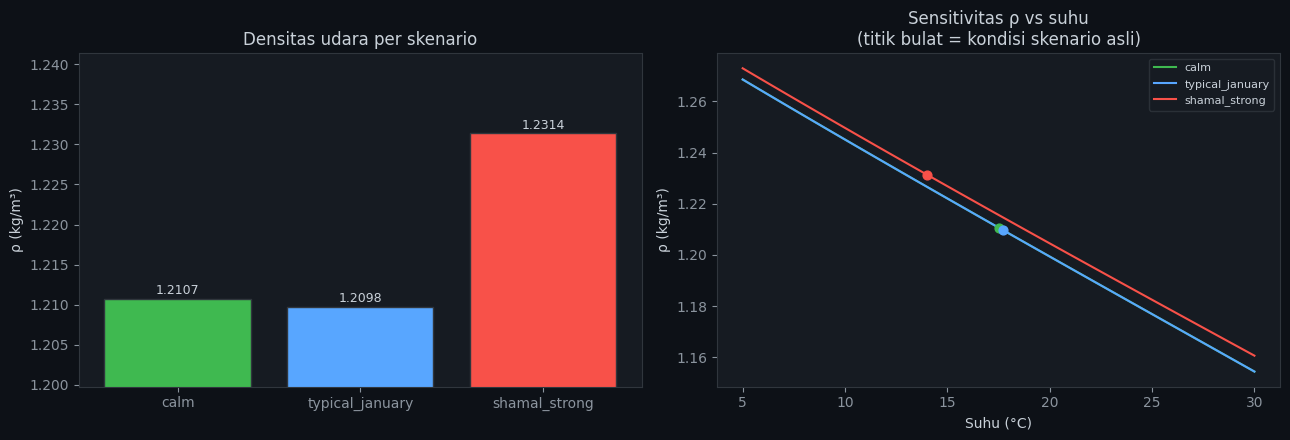

Rentang densitas antar skenario: 1.2098 - 1.2314 kg/m^3 (1.8% spread)


In [3]:
densities = {name: weather_mod.air_density(s) for name, s in weather_mod.SCENARIOS.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

names = list(densities.keys())
vals = [densities[n] for n in names]
colors = [SCENARIO_COLOR[n] for n in names]
bars = ax1.bar(names, vals, color=colors, edgecolor="#30363d")
ax1.set_ylabel("ρ (kg/m³)")
ax1.set_title("Densitas udara per skenario")
ax1.set_ylim(min(vals) - 0.01, max(vals) + 0.01)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.0006, f"{v:.4f}", ha="center", fontsize=9)

# Sensitivity sweep: rho vs temperature at each scenario's own RH/pressure, holding wind fixed --
# shows temperature dominates rho far more than the RH swing between scenarios (17.5% -> 65% -> 50%).
t_sweep = np.linspace(5, 30, 60)
for name, s in weather_mod.SCENARIOS.items():
    rho_sweep = [weather_mod.air_density(weather_mod.WeatherScenario(
        name=name, temperature_c=t, relative_humidity=s.relative_humidity,
        pressure_hpa=s.pressure_hpa, wind_speed_kmh=s.wind_speed_kmh,
        wind_from_bearing_deg=s.wind_from_bearing_deg, confidence="", source="")) for t in t_sweep]
    ax2.plot(t_sweep, rho_sweep, color=SCENARIO_COLOR[name], label=name)
    ax2.scatter([s.temperature_c], [weather_mod.air_density(s)], color=SCENARIO_COLOR[name], zorder=5, s=40)
ax2.set_xlabel("Suhu (°C)")
ax2.set_ylabel("ρ (kg/m³)")
ax2.set_title("Sensitivitas ρ vs suhu\n(titik bulat = kondisi skenario asli)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("assets/plot_weather_density.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

spread_pct = (max(vals) - min(vals)) / min(vals) * 100
print(f"Rentang densitas antar skenario: {min(vals):.4f} - {max(vals):.4f} kg/m^3 ({spread_pct:.1f}% spread)")

## 3. Tahap 2 — Headwind Component & Airspeed Relatif

Drag bergantung pada kecepatan mobil **relatif terhadap udara**, bukan relatif terhadap tanah. Kalau
angin datang dari depan (headwind), airspeed efektif lebih besar dari ground speed → drag naik; kalau
dari belakang (tailwind), sebaliknya.

Langkahnya (`weather_mod.headwind_component_kmh`):

1. Bearing **arah datang** angin dikonversi ke bearing **arah gerak** angin: $+180°$.
2. Diproyeksikan ke heading track lewat $\cos(\Delta\theta)$ antara arah gerak angin dan arah gerak mobil.
3. Hasilnya dinegasikan supaya konvensi tandanya `positive = headwind, negative = tailwind`.

Model ini **hanya** memakai komponen fore-aft (searah gerak) — crosswind murni (90°) secara model punya
kontribusi drag nol karena `CdA` cuma satu nilai frontal tanpa data yaw. Karena track Lusail berupa
loop tertutup, heading mobil berputar penuh 0–360° satu lap — jadi setiap skenario angin akan
menghasilkan headwind di sebagian track dan tailwind di sisanya, tergantung arah loop relatif ke arah
angin.

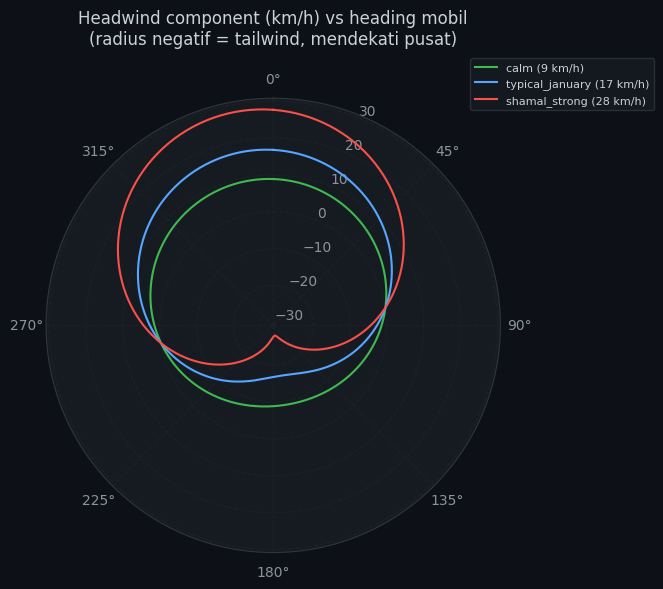

In [4]:
headings = np.linspace(0, 360, 361)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)  # compass convention: clockwise from North

for name, s in weather_mod.SCENARIOS.items():
    hw = [weather_mod.headwind_component_kmh(s, float(h)) for h in headings]
    ax.plot(np.radians(headings), hw, color=SCENARIO_COLOR[name], label=f"{name} ({s.wind_speed_kmh:.0f} km/h)")

ax.set_title("Headwind component (km/h) vs heading mobil\n(radius negatif = tailwind, mendekati pusat)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig("assets/plot_weather_headwind_polar.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 4. Diterapkan ke Track Asli — Di Mana Angin Paling Terasa?

Plot polar di atas abstrak (heading 0–360° generik). Sekarang pakai **heading asli tiap titik** di
track Lusail (`track.build_track_profile()`, kolom `heading_deg` yang sudah dipakai simulator produksi)
supaya kelihatan **di kilometer berapa** headwind/tailwind itu benar-benar terjadi sepanjang satu lap.

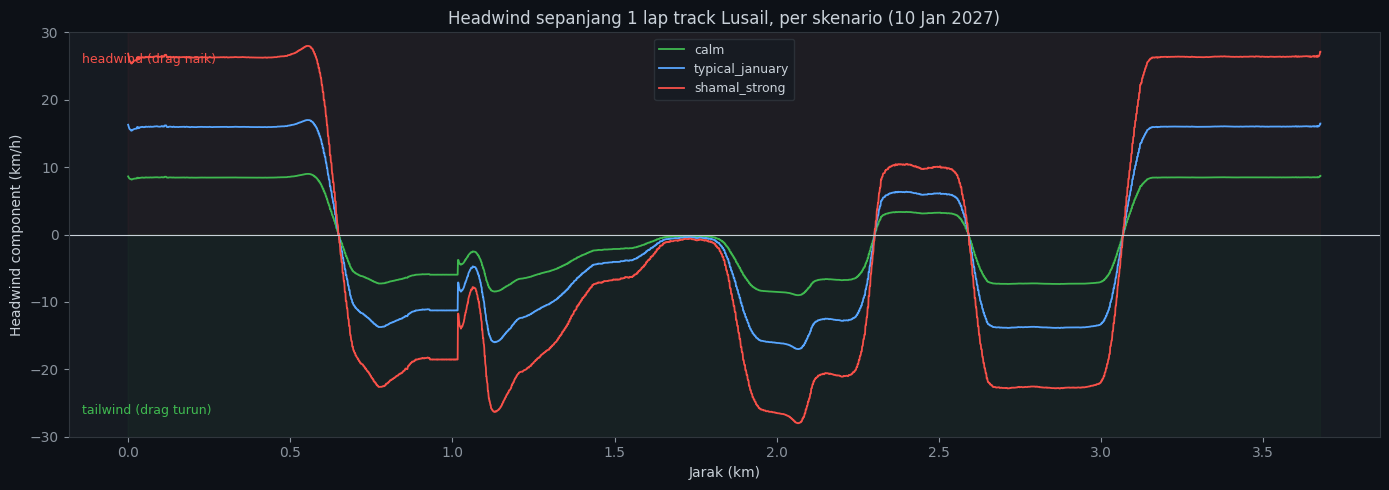

,mean_headwind_kmh,pct_track_headwind,worst_headwind_kmh,best_tailwind_kmh
scenario,,,,
calm,-0.00,42.13,9.0,-9.0
typical_january,-0.00,42.13,17.0,-17.0
shamal_strong,-0.01,42.13,28.0,-28.0


In [5]:
profile = track_mod.build_track_profile(save=False)

fig, ax = plt.subplots(figsize=(14, 5))
for name, s in weather_mod.SCENARIOS.items():
    hw_along_track = profile["heading_deg"].apply(lambda h: weather_mod.headwind_component_kmh(s, h))
    ax.plot(profile["distance_km"], hw_along_track, color=SCENARIO_COLOR[name], label=name, linewidth=1.3)

ax.axhline(0, color="#c9d1d9", linewidth=0.8, linestyle="-")
ax.fill_between(profile["distance_km"], 0, 200, color="#f85149", alpha=0.04)
ax.fill_between(profile["distance_km"], -200, 0, color="#3fb950", alpha=0.04)
ax.set_ylim(-30, 30)
ax.text(0.01, 0.95, "headwind (drag naik)", transform=ax.transAxes, color="#f85149", fontsize=9, va="top")
ax.text(0.01, 0.05, "tailwind (drag turun)", transform=ax.transAxes, color="#3fb950", fontsize=9, va="bottom")
ax.set_xlabel("Jarak (km)")
ax.set_ylabel("Headwind component (km/h)")
ax.set_title("Headwind sepanjang 1 lap track Lusail, per skenario (10 Jan 2027)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/plot_weather_headwind_track.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

summary_rows = []
for name, s in weather_mod.SCENARIOS.items():
    hw = profile["heading_deg"].apply(lambda h: weather_mod.headwind_component_kmh(s, h))
    summary_rows.append({
        "scenario": name,
        "mean_headwind_kmh": hw.mean(),
        "pct_track_headwind": (hw > 0).mean() * 100,
        "worst_headwind_kmh": hw.max(),
        "best_tailwind_kmh": hw.min(),
    })
pd.DataFrame(summary_rows).set_index("scenario").round(2)

## 5. Peta Panas Headwind/Tailwind di Track Lusail

Grafik "headwind vs jarak" di atas sudah menunjukkan di km berapa angin melawan/membantu, tapi belum
menunjukkan **bentuk spasialnya** di track. Sekarang plot ulang nilai yang sama (`headwind_component_kmh`
per titik, per skenario) sebagai **heatmap di atas bentuk track sebenarnya** (proyeksi lat/lon ke
bidang lokal meter Timur–Utara, sama seperti peta-peta di `Track_Analysis.ipynb`) — supaya kelihatan
langsung segmen/tikungan mana yang paling terkena headwind (merah) vs paling terbantu tailwind (biru),
bukan cuma di kilometer berapa.

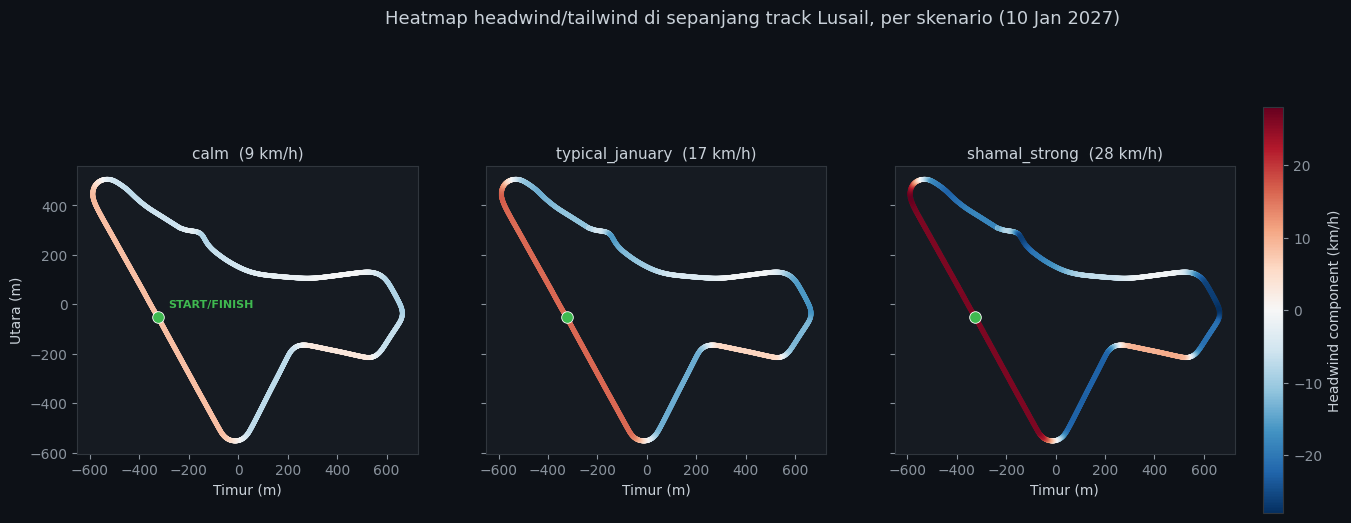

In [6]:
import math

# Proyeksi flat-earth lokal (Timur/Utara, meter) -- origin di titik rata-rata track,
# format sama dengan racing_line.py/track_edges_imagery convention, tanpa rotasi
# (cukup untuk heatmap, tidak perlu sejajar dengan peta Track_Analysis.ipynb).
_lat0 = profile["latitude"].mean()
_lon0 = profile["longitude"].mean()
_mlat = 111132.954 - 559.822 * math.cos(2 * math.radians(_lat0))
_mlon = 111412.84 * math.cos(math.radians(_lat0))
map_x = (profile["longitude"].to_numpy() - _lon0) * _mlon
map_y = (profile["latitude"].to_numpy() - _lat0) * _mlat

heading = profile["heading_deg"].to_numpy()
hw_by_scenario = {
    name: np.array([weather_mod.headwind_component_kmh(s, float(h)) for h in heading])
    for name, s in weather_mod.SCENARIOS.items()
}
# Shared color scale across all 3 panels (not per-panel normalized) so the
# stronger wind in shamal_strong visibly reads as MORE saturated color, not
# just a differently-scaled version of the same picture.
vmax = max(np.abs(hw).max() for hw in hw_by_scenario.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 6.2), sharex=True, sharey=True)
sc = None
for ax, (name, hw) in zip(axes, hw_by_scenario.items()):
    ax.plot(map_x, map_y, color="#30363d", linewidth=4, zorder=1, solid_capstyle="round")
    sc = ax.scatter(map_x, map_y, c=hw, cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=6, zorder=2)
    ax.scatter([map_x[0]], [map_y[0]], color="#3fb950", s=70, zorder=3, edgecolor="white", linewidth=0.6)
    ax.set_title(f"{name}  ({weather_mod.SCENARIOS[name].wind_speed_kmh:.0f} km/h)", fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlabel("Timur (m)")
axes[0].set_ylabel("Utara (m)")
axes[0].annotate("START/FINISH", xy=(map_x[0], map_y[0]), xytext=(map_x[0] + 40, map_y[0] + 40),
                  color="#3fb950", fontsize=8, fontweight="bold")

cbar = fig.colorbar(sc, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("Headwind component (km/h)")
fig.suptitle("Heatmap headwind/tailwind di sepanjang track Lusail, per skenario (10 Jan 2027)", fontsize=13)
plt.savefig("assets/plot_weather_headwind_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 6. Dampak ke Drag Force — Kenapa Ini Penting untuk Strategi

Terakhir, hubungkan kembali ke fisika yang benar-benar dipakai simulator: `vehicle.drag_force_n()`
mengambil `rho` dan `v_rel` dari `weather.py`, lalu `CdA` (tetap, dari CFD) di-lookup pada **airspeed
relatif** itu (bukan ground speed). Dihitung pada kecepatan cruise representatif (30 km/h, dekat rentang
DP-optimal) sepanjang track yang sama, dibandingkan ke baseline hipotetis tanpa angin sama sekali (angin
0 km/h, tapi ρ skenario tetap dipakai) supaya efek **angin doang** kelihatan terpisah dari efek densitas.

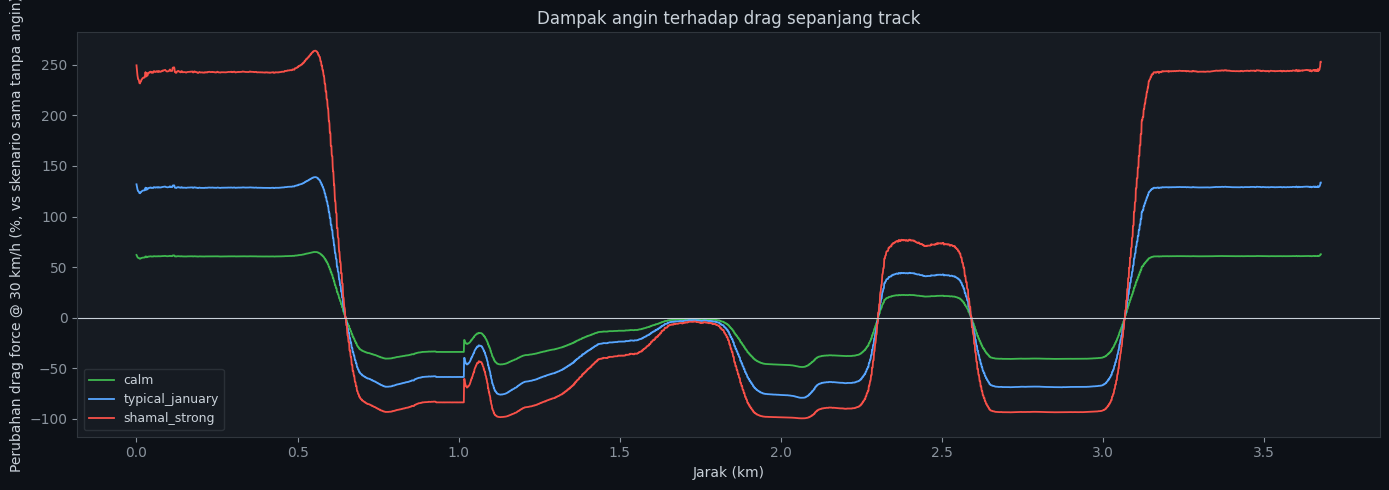

calm            :   0.61 kJ ekstra kerja-drag per lap (murni dari angin, @ 30 km/h konstan)
typical_january :   2.20 kJ ekstra kerja-drag per lap (murni dari angin, @ 30 km/h konstan)
shamal_strong   :   6.12 kJ ekstra kerja-drag per lap (murni dari angin, @ 30 km/h konstan)


In [7]:
V_REF_KMH = 30.0

fig, ax = plt.subplots(figsize=(14, 5))
extra_energy_j = {}
for name, s in weather_mod.SCENARIOS.items():
    no_wind = weather_mod.WeatherScenario(name=name + "_no_wind", temperature_c=s.temperature_c,
                                           relative_humidity=s.relative_humidity, pressure_hpa=s.pressure_hpa,
                                           wind_speed_kmh=0.0, wind_from_bearing_deg=s.wind_from_bearing_deg,
                                           confidence="", source="")
    f_wind = profile["heading_deg"].apply(lambda h: vehicle_mod.drag_force_n(V_REF_KMH, s, h))
    f_calm = profile["heading_deg"].apply(lambda h: vehicle_mod.drag_force_n(V_REF_KMH, no_wind, h))
    delta_pct = (f_wind - f_calm) / f_calm * 100
    ax.plot(profile["distance_km"], delta_pct, color=SCENARIO_COLOR[name], label=name, linewidth=1.3)

    seg_m = np.gradient(profile["distance_km"].to_numpy()) * 1000.0
    extra_energy_j[name] = float(((f_wind - f_calm).to_numpy() * seg_m).sum())

ax.axhline(0, color="#c9d1d9", linewidth=0.8)
ax.set_xlabel("Jarak (km)")
ax.set_ylabel(f"Perubahan drag force @ {V_REF_KMH:.0f} km/h (%, vs skenario sama tanpa angin)")
ax.set_title("Dampak angin terhadap drag sepanjang track")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/plot_weather_drag_impact.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

for name, j in extra_energy_j.items():
    sign = "ekstra" if j >= 0 else "hemat"
    print(f"{name:16s}: {abs(j)/1000:6.2f} kJ {sign} kerja-drag per lap (murni dari angin, @ {V_REF_KMH:.0f} km/h konstan)")

## 7. Ringkasan

- **`shamal_strong`** (angin kuat 28 km/h dari NNW) adalah skenario yang paling relevan untuk uji
  robustness strategi — bukan cuma karena anginnya paling kencang, tapi karena kombinasi suhu/kelembapan
  yang lebih rendah (udara pasca-front lebih dingin & kering) memberi ρ yang sedikit lebih tinggi juga,
  jadi dua efek (ρ naik + headwind di sebagian besar track) menumpuk ke arah yang sama.
- Efek densitas murni (Bagian 2) jauh lebih kecil daripada efek angin (Bagian 4–5) pada rentang kondisi
  Januari Lusail — suhu/kelembapan cuma menggeser ρ sedikit, sedangkan headwind langsung menaikkan
  airspeed relatif secara linear.
- Ketiga skenario ini (`weather_mod.SCENARIOS`) adalah **input**, bukan hasil — dipakai sebagai argumen
  `scenario` di `simulate.simulate()`/`optimize_dp.py`/`optimize_ga.py`/`optimize_pso.py`/
  `optimize_cma.py`/`mpc.py`, jadi tiap hasil optimasi (DP/GA/PSO/CMA/MPC) yang selama ini dilaporkan
  di notebook lain dihitung di **satu** skenario terpilih (biasanya `typical_january`) — sweep robustness
  penuh di 3 skenario sekaligus untuk strategi akhir masih **belum dikerjakan** (lihat catatan "Next" di
  demo notebook utama).
